In [1]:
from langchain_community.document_loaders import PyMuPDFLoader

# 문서 로드
loader = PyMuPDFLoader('../data/KCI_FI003153549.pdf')
documents = loader.load()

In [ ]:
documents

In [3]:
print(documents[1].page_content)

170   Journal of The Korea Society of Computer and Information 
[요   약]
본 연구는 대규모 언어 모델(LLM) 기반의 Private LLM을 활용하여 의료기기 임상시험 분야에 
적용하여 업무 효율성과 전문성 향상을 탐구한다. Private LLM 시스템은 임상 데이터를 기반으로 
정교하고 정확한 답변을 제공하며, 의사결정 지원, 임상 전문가 활동 보조, 새로운 콘텐츠 생성, 
문제 해결 등 다양한 응용 분야에서 활용 가능성을 보여준다. 연구는 다음 네 가지 주요 단계로 
구성된다. 첫째, 의료기기 임상시험에 특화된 데이터를 수집하고 이를 전처리하여 학습 가능한 형
식으로 정리한다. 둘째, LLaMA와 같은 오픈소스 LLM 모델을 기반으로 PEFT(LoRA) 및 RAG 기
법을 적용하여 특정 임상 도메인에 맞는 맞춤형 Private LLM 질의응답 시스템을 구축한다. 셋째, 
구축된 시스템을 활용하여 전문가 수준의 질의응답 기능을 실현하고, 임상시험 운영 중 발생하는 
복잡한 질문과 문제를 해결한다. 마지막으로, 시스템의 성능을 평가하여 임상시험 운영과 의료기
기 개발의 효율성과 신뢰성을 높이기 위한 방향성을 제안한다. 연구 결과, Private LLM 시스템은 
기존의 방법론 대비 업무 자동화와 정밀한 의사결정 지원에서 탁월한 성능을 보였다. 특히, 도메
인 전문가의 질문에 대한 정확한 답변을 제공하고, 새로운 임상 기준 및 인사이트를 생성할 수 
있는 능력은 의료기기 임상시험 운영의 혁신적 도구로 자리잡을 가능성을 보여준다. 이를 통해 
정밀 의료, 임상시험 관리 자동화, 그리고 도메인 지식 기반의 질의응답 시스템에서 Private LLM
의 실질적 활용 가능성을 확인하였다.
▸주제어: 대규모 언어 모델, 생성형 인공지능, 임상시험, 의료기기, 데이터 분석
I. Introduction
대규모 언어 모델(Large Language Models, LLM)의 
발전은 최근 몇 년간 인공지능(AI) 기술의 중요

In [4]:
documents[1].metadata

{'producer': 'ezPDF Builder Supreme',
 'creator': '',
 'creationdate': '2024-12-27T02:09:00+09:00',
 'source': '../data/KCI_FI003153549.pdf',
 'file_path': '../data/KCI_FI003153549.pdf',
 'total_pages': 12,
 'format': 'PDF 1.6',
 'title': '',
 'author': '',
 'subject': '',
 'keywords': '',
 'moddate': '2024-12-27T02:09:00+09:00',
 'trapped': '',
 'modDate': "D:20241227020900+09'00'",
 'creationDate': "D:20241227020900+09'00'",
 'page': 1}

In [5]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# 문서 분할
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
)
splitted_documents = text_splitter.split_documents(documents)

In [6]:
len(splitted_documents)

42

In [7]:
print(splitted_documents[0].page_content)

JKSCI
한국컴퓨터정보학회논문지
Journal of The Korea Society of Computer and Information
Vol. 29 No. 12, pp. 169-180, December 2024
https://doi.org/10.9708/jksci.2024.29.12.169
Clinical Trials Utilizing LLM-Based Generative AI
1)Hyon-Chel Jung*,  Kun-Soo Shin**,  Ho-Dong Kim***,  Sung-Bin Park****
*Research Professor, Dept. of Institute of Artificial Intelligence and Big Data in Medicine, Yonsei University 
Wonju College of Medicine, Korea 
**Researcher, Dept. of Yonsei University Future Medical Industry Cooperation Group, Korea
***Executive Vice President, Head of AI, Corporate Research Institute, Solbit Co., Ltd., Korea
****Professor, Dept. of Precision Medicine, Yonsei University Wonju College of Medicine, Korea
[Abstract]
This study explores the improvement of work efficiency and expertise by applying Private LLM 
based on Large Language Model (LLM) to the field of clinical trials in medical devices. The Private


In [8]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from dotenv import load_dotenv
load_dotenv()

# 임베딩 모델 준비
embedding_model = GoogleGenerativeAIEmbeddings(
    model="gemini-embedding-001",
)

#### 벡터스토어 로컬 저장 예제

In [9]:
from langchain_community.vectorstores import FAISS

# FAISS 벡터스토어 생성 및 저장
vectorstore = FAISS.from_documents(splitted_documents, embedding_model)
vectorstore.save_local("faiss_index")

# 벡터스토어 재로딩
vectorstore = FAISS.load_local(
    "faiss_index",
    embedding_model,
    allow_dangerous_deserialization=True,
)

In [10]:
vectorstore

#### `as_retriever()` 메서드

In [11]:
# 리트리버 생성
retriever = vectorstore.as_retriever()

In [12]:
retriever

VectorStoreRetriever(tags=['FAISS', 'GoogleGenerativeAIEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x00000210403FD1D0>, search_kwargs={})

In [13]:
# 예시 질의
query = "본 연구에서 Private LLM 구축을 위해 수집한 문서의 총 페이지 수와 문서 유형별 비율은 어떻게 되나요?"

In [14]:
retriever.invoke(query)

[Document(id='aa721ab4-ed0a-48b0-8d31-79474b86551f', metadata={'producer': 'ezPDF Builder Supreme', 'creator': '', 'creationdate': '2024-12-27T02:09:00+09:00', 'source': '../data/KCI_FI003153549.pdf', 'file_path': '../data/KCI_FI003153549.pdf', 'total_pages': 12, 'format': 'PDF 1.6', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2024-12-27T02:09:00+09:00', 'trapped': '', 'modDate': "D:20241227020900+09'00'", 'creationDate': "D:20241227020900+09'00'", 'page': 4}, page_content='의료기기 임상시험 분야의 도메인 특성에 맞게 튜닝하\n기 위해 의료기기 임상시험 전문가로부터 총 158개의 문\n서(총 11,954 페이지)를 수집하였다. 수집된 문서는 다음\n과 같이 분류된다:\ny 규제 문서 (30%): FDA, EMA, PMDA 가이드라인, \nGCP 문서 등\ny 교육 자료 (20%): 임상시험 수행자 교육 매뉴얼, 온라\n인 강의 자료 등\ny 프로토콜 및 보고서 (25%): 임상시험 프로토콜, CSR \n(Clinical Study Report) 템플릿 등\ny 의료기기 특화 문서 (15%): 의료기기 임상시험 계획\n서, 기술문서 등\ny 기타 (10%): 윤리위원회 관련 문서, 환자 동의서 템플\n릿 등\n1.2 Validity of Collected Data\n수집된 \n데이터셋은 \n의료기기 \n임상시험에 \n특화된 \nPrivate LLM 구축을 위해 도메인 적합성과 다양성, 그리\n고 응용 가능성 측면에서 높은 타당성을 갖추고 있다. 

In [15]:
from langchain_core.prompts import PromptTemplate

prompt = PromptTemplate.from_template(
    '''다음 컨텍스트만 사용해 질문에 답하세요.
컨텍스트:{context}

질문: {question}
'''
)

In [16]:
prompt

PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template='다음 컨텍스트만 사용해 질문에 답하세요.\n컨텍스트:{context}\n\n질문: {question}\n')

In [17]:
# 질문 예시
# query = "Advance RAG 기법이 임상시험 데이터 분석에서 수행하는 주요 역할은 무엇인가요?"
# query = "본 연구에서 Private LLM 성능을 평가하기 위해 사용한 지표 3가지는 무엇인가요?"
query = "본 연구에서 Private LLM 구축을 위해 수집한 문서의 총 페이지 수와 문서 유형별 비율은 어떻게 되나요?"
# query = "ROUGE 평가에서 Private LLM과 ChatGPT의 Recall 값은 각각 얼마였나요?"

In [18]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.output_parsers import StrOutputParser

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

chain = prompt | llm | StrOutputParser()

In [19]:
results = vectorstore.similarity_search(query, k=5) # 검색을 외부에서 미리 실행한 후 반환된 결과 사용

In [20]:
response = chain.invoke({'context': results, 'question': query})

In [21]:
print(response)

본 연구에서 Private LLM 구축을 위해 수집한 문서의 총 페이지 수는 **11,954 페이지**입니다.

문서 유형별 비율은 다음과 같습니다:
*   **규제 문서**: 30% (FDA, EMA, PMDA 가이드라인, GCP 문서 등)
*   **교육 자료**: 20% (임상시험 수행자 교육 매뉴얼, 온라인 강의 자료 등)
*   **프로토콜 및 보고서**: 25% (임상시험 프로토콜, CSR 템플릿 등)
*   **의료기기 특화 문서**: 15% (의료기기 임상시험 계획서, 기술문서 등)
*   **기타**: 10% (윤리위원회 관련 문서, 환자 동의서 템플릿 등)


### LangGraph RAG

In [22]:
from typing_extensions import List, TypedDict
from langchain_core.documents import Document

class AgentState(TypedDict):
    query: str
    context: List[Document]
    answer: str

In [23]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(AgentState)

In [24]:
def retrieve(state: AgentState) -> AgentState:
    """
    사용자의 질문에 기반하여 벡터 스토어에서 관련 문서를 검색합니다.

    Args:
        state (AgentState): 사용자의 질문을 포함한 에이전트의 현재 state.

    Returns:
        AgentState: 검색된 문서가 추가된 state를 반환합니다.
    """
    query = state['query']  # state에서 사용자의 질문을 추출합니다.
    docs = retriever.invoke(query)  # 질문과 관련된 문서를 검색합니다.
    return {'context': docs}  # 검색된 문서를 포함한 state를 반환합니다.

In [25]:
# LangChain의 hub에 정의된 검증된 RAG 프롬프트 활용
# https://smith.langchain.com/hub
# rlm: LangChain 팀이 공식적으로 유지보수하는 프롬프트를 의미
# rag-prompt: 해당 소유자가 게시한 프롬프트의 이름
from langchain import hub
prompt = hub.pull("rlm/rag-prompt")

In [26]:
prompt

ChatPromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, metadata={'lc_hub_owner': 'rlm', 'lc_hub_repo': 'rag-prompt', 'lc_hub_commit_hash': '50442af133e61576e74536c6556cefe1fac147cad032f4377b60c436e6cdcb6e'}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template="You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.\nQuestion: {question} \nContext: {context} \nAnswer:"), additional_kwargs={})])

In [27]:
prompt.messages[0].prompt.template

"You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.\nQuestion: {question} \nContext: {context} \nAnswer:"

In [28]:
def generate(state: AgentState) -> AgentState:
    """
    사용자의 질문과 검색된 문서를 기반으로 응답을 생성합니다.

    Args:
        state (AgentState): 사용자의 질문과 검색된 문서를 포함한 에이전트의 현재 state.

    Returns:
        AgentState: 생성된 응답이 추가된 state를 반환합니다.
    """
    context = state['context']  # state에서 검색된 문서를 추출합니다.
    query = state['query']  # state에서 사용자의 질문을 추출합니다.
    rag_chain = prompt | llm  # RAG 프롬프트와 LLM을 연결하여 체인을 만듭니다.
    response = rag_chain.invoke({'question': query, 'context': context})  # 질문과 문맥을 사용하여 응답을 생성합니다.
    return {'answer': response}  # 생성된 응답을 포함한 state를 반환합니다.

In [29]:
graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)

In [30]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'retrieve')
graph_builder.add_edge('retrieve', 'generate')
graph_builder.add_edge('generate', END)

In [31]:
graph = graph_builder.compile()

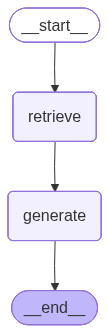

In [32]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [33]:
initial_state = {'query': query}
result = graph.invoke(initial_state)

In [34]:
result

{'query': '본 연구에서 Private LLM 구축을 위해 수집한 문서의 총 페이지 수와 문서 유형별 비율은 어떻게 되나요?',
 'context': [Document(id='aa721ab4-ed0a-48b0-8d31-79474b86551f', metadata={'producer': 'ezPDF Builder Supreme', 'creator': '', 'creationdate': '2024-12-27T02:09:00+09:00', 'source': '../data/KCI_FI003153549.pdf', 'file_path': '../data/KCI_FI003153549.pdf', 'total_pages': 12, 'format': 'PDF 1.6', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2024-12-27T02:09:00+09:00', 'trapped': '', 'modDate': "D:20241227020900+09'00'", 'creationDate': "D:20241227020900+09'00'", 'page': 4}, page_content='의료기기 임상시험 분야의 도메인 특성에 맞게 튜닝하\n기 위해 의료기기 임상시험 전문가로부터 총 158개의 문\n서(총 11,954 페이지)를 수집하였다. 수집된 문서는 다음\n과 같이 분류된다:\ny 규제 문서 (30%): FDA, EMA, PMDA 가이드라인, \nGCP 문서 등\ny 교육 자료 (20%): 임상시험 수행자 교육 매뉴얼, 온라\n인 강의 자료 등\ny 프로토콜 및 보고서 (25%): 임상시험 프로토콜, CSR \n(Clinical Study Report) 템플릿 등\ny 의료기기 특화 문서 (15%): 의료기기 임상시험 계획\n서, 기술문서 등\ny 기타 (10%): 윤리위원회 관련 문서, 환자 동의서 템플\n릿 등\n1.2 Validity of Collected Data\n수집된 \n데이터셋은 \n

In [35]:
result['answer'].content

'본 연구에서 Private LLM 구축을 위해 수집한 문서는 총 11,954 페이지입니다. 수집된 문서는 규제 문서 30%, 교육 자료 20%, 프로토콜 및 보고서 25%, 의료기기 특화 문서 15%, 기타 문서 10%로 구성됩니다.'